/tmp/ipykernel_1399/480983605.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  transactions['Transaction_DateTime'] = pd.to_datetime(transactions['Transaction_DateTime'])


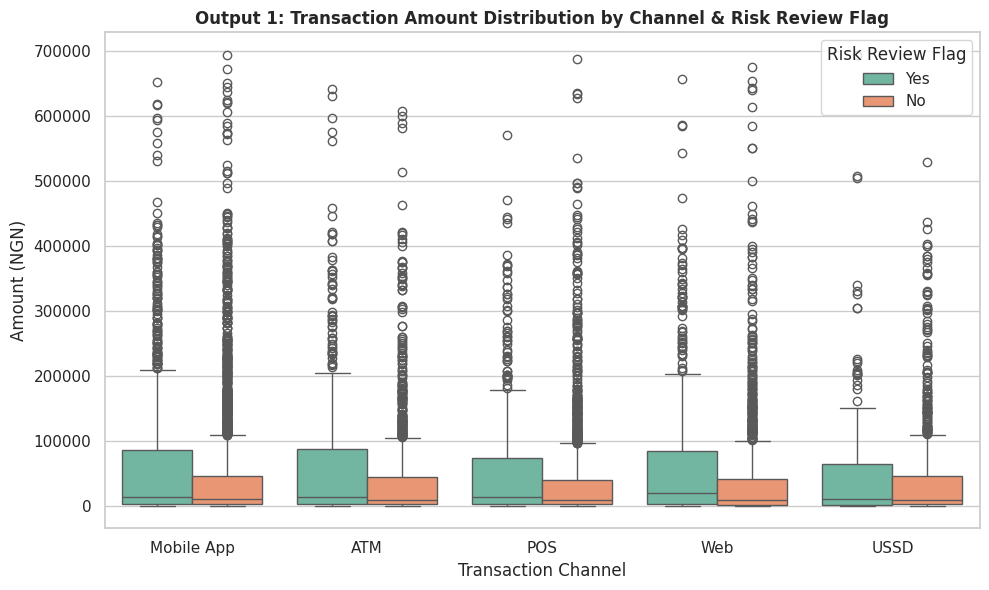

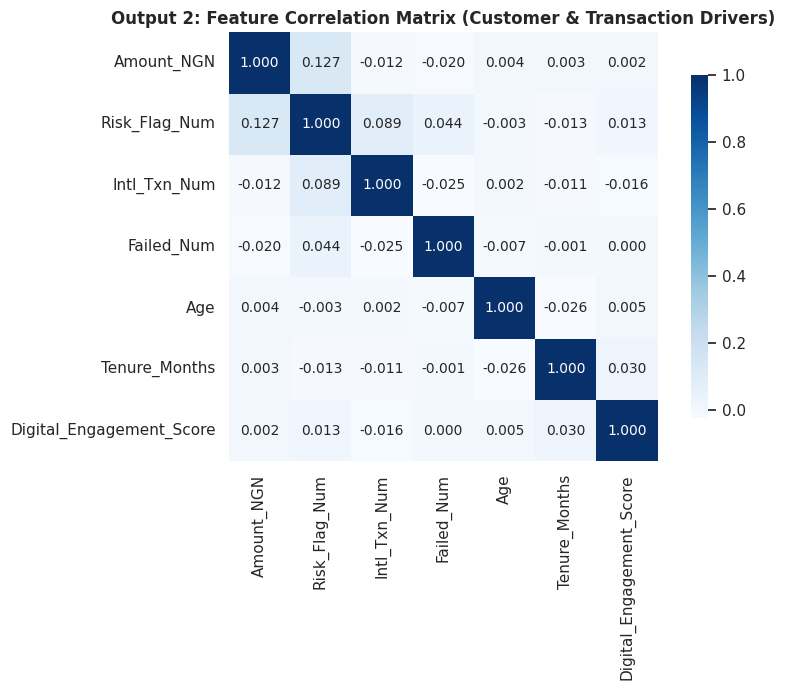

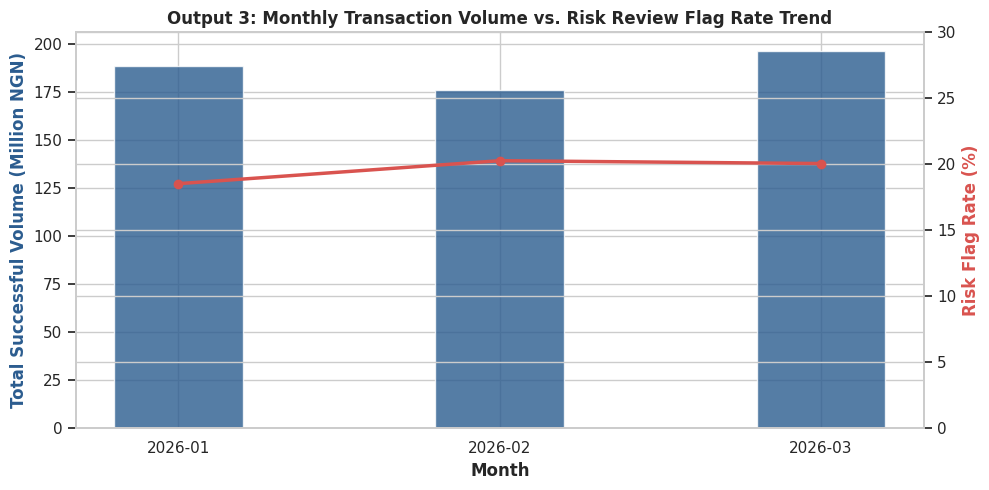

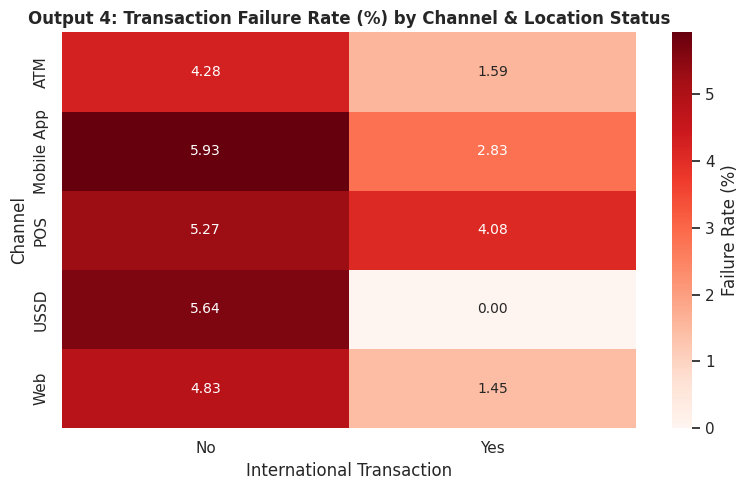

/tmp/ipykernel_1399/480983605.py:93: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_age_risk = df.groupby(['Age_Group', 'Customer_Segment'])['Risk_Flag_Num'].mean().unstack() * 100


<Figure size 1000x500 with 0 Axes>

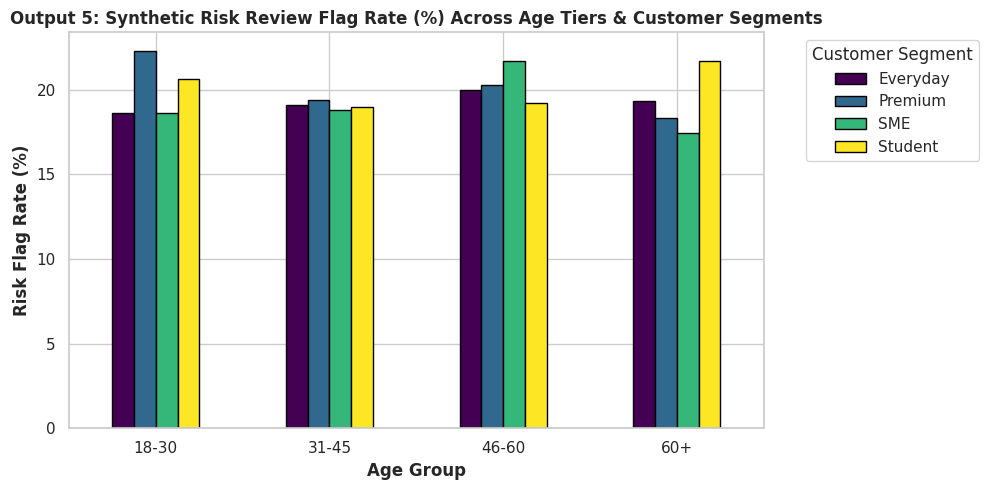

Execution complete! All 5 visualizations generated successfully in Colab.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual theme
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 10

# 1. Load CSV Files directly as named in your Colab files panel
customers = pd.read_csv('FINTRUST CUSTOMER DATA (1).csv')
transactions = pd.read_csv('FINTRUST TRANSACTION DATA.csv')

# Clean headers and convert datetime
customers.columns = [c.strip() for c in customers.columns]
transactions.columns = [c.strip() for c in transactions.columns]
transactions['Transaction_DateTime'] = pd.to_datetime(transactions['Transaction_DateTime'])

# Merge into unified dataframe
df = pd.merge(transactions, customers, on='Customer_ID', how='inner')

# Create binary metrics for analysis
df['Risk_Flag_Num'] = (df['Risk_Review_Flag'] == 'Yes').astype(int)
df['Intl_Txn_Num'] = (df['International_Transaction'] == 'Yes').astype(int)
df['Failed_Num'] = (df['Transaction_Status'] == 'Failed').astype(int)

# =============================================================================
# OUTPUT 1: Distribution & Outliers in Transaction Amounts by Channel
# =============================================================================
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Channel', y='Amount_NGN', hue='Risk_Review_Flag', palette='Set2')
plt.title('Output 1: Transaction Amount Distribution by Channel & Risk Review Flag', fontsize=12, fontweight='bold')
plt.xlabel('Transaction Channel')
plt.ylabel('Amount (NGN)')
plt.legend(title='Risk Review Flag')
plt.tight_layout()
plt.savefig('output_1_channel_amount_risk.png')
plt.show()

# =============================================================================
# OUTPUT 2: Feature Correlation Matrix
# =============================================================================
plt.figure(figsize=(9, 7))
corr_cols = ['Amount_NGN', 'Risk_Flag_Num', 'Intl_Txn_Num', 'Failed_Num', 'Age', 'Tenure_Months', 'Digital_Engagement_Score']
corr_matrix = df[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='Blues', square=True, cbar_kws={'shrink': .8})
plt.title('Output 2: Feature Correlation Matrix (Customer & Transaction Drivers)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('output_2_correlation_heatmap.png')
plt.show()

# =============================================================================
# OUTPUT 3: Monthly Volume & Risk Flag Trend
# =============================================================================
df['YearMonth'] = df['Transaction_DateTime'].dt.to_period('M')
monthly_agg = df.groupby('YearMonth').agg(
    total_volume=('Amount_NGN', 'sum'),
    risk_flag_rate=('Risk_Flag_Num', 'mean')
).reset_index()
monthly_agg['YearMonth_Str'] = monthly_agg['YearMonth'].astype(str)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.bar(monthly_agg['YearMonth_Str'], monthly_agg['total_volume'] / 1e6, color='#2b5c8f', alpha=0.8, width=0.4, label='Total Volume (Millions NGN)')
ax2.plot(monthly_agg['YearMonth_Str'], monthly_agg['risk_flag_rate'] * 100, color='#d9534f', marker='o', linewidth=2.5, label='Risk Review Flag Rate (%)')
ax1.set_xlabel('Month', fontweight='bold')
ax1.set_ylabel('Total Successful Volume (Million NGN)', color='#2b5c8f', fontweight='bold')
ax2.set_ylabel('Risk Flag Rate (%)', color='#d9534f', fontweight='bold')
ax2.set_ylim(0, 30)
plt.title('Output 3: Monthly Transaction Volume vs. Risk Review Flag Rate Trend', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.savefig('output_3_monthly_volume_risk_trend.png')
plt.show()

# =============================================================================
# OUTPUT 4: Failure Rate Matrix by Channel and Location
# =============================================================================
failure_matrix = df.pivot_table(index='Channel', columns='International_Transaction', values='Failed_Num', aggfunc='mean') * 100
plt.figure(figsize=(8, 5))
sns.heatmap(failure_matrix, annot=True, fmt='.2f', cmap='Reds', cbar_kws={'label': 'Failure Rate (%)'})
plt.title('Output 4: Transaction Failure Rate (%) by Channel & Location Status', fontsize=12, fontweight='bold')
plt.xlabel('International Transaction')
plt.ylabel('Channel')
plt.tight_layout()
plt.savefig('output_4_failure_rate_matrix.png')
plt.show()

# =============================================================================
# OUTPUT 5: Risk Rate Across Age Tiers & Segments
# =============================================================================
df['Age_Group'] = pd.cut(df['Age'], bins=[17, 30, 45, 60, 100], labels=['18-30', '31-45', '46-60', '60+'])
segment_age_risk = df.groupby(['Age_Group', 'Customer_Segment'])['Risk_Flag_Num'].mean().unstack() * 100

plt.figure(figsize=(10, 5))
segment_age_risk.plot(kind='bar', figsize=(10, 5), colormap='viridis', edgecolor='black')
plt.title('Output 5: Synthetic Risk Review Flag Rate (%) Across Age Tiers & Customer Segments', fontsize=12, fontweight='bold')
plt.xlabel('Age Group', fontweight='bold')
plt.ylabel('Risk Flag Rate (%)', fontweight='bold')
plt.legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('output_5_risk_rate_age_segment.png')
plt.show()

print("Execution complete! All 5 visualizations generated successfully in Colab.")